Here, we’ll build a caption-matching AI system that:

* Takes an input image (say, a cup of tea)
* Compares it to a list of 70+ potential captions
* Returns the Top 5 captions that best describe the image, using cosine similarity

We’ll build all of this using Python, PyTorch, and Hugging Face Transformers.

Now let’s get started with building a multimodal AI model with Python step-by-step.

Step 1: Load and Preprocess the Image

We’ll use Pillow to load the image and CLIPProcessor to tokenize it for the CLIP model:

In [ ]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel, AutoProcessor, AutoModelForCausalLM
import io

# image loading and preprocessing
def load_and_preprocess_image(image_path):
    image = Image.open(io.BytesIO(uploaded[image_path])).convert("RGB")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    inputs = processor(images=image, return_tensors="pt")
    return inputs, processor

This will convert the image into a tensor that the CLIP model can process.

Step 2: Extract Image Embeddings with CLIP

Next, we’ll use CLIPModel to extract feature embeddings from the image:

In [ ]:
# image understanding with CLIP
def generate_image_embeddings(inputs):
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)

    return image_features, model

This will give us a vector that captures the semantic meaning of the image.

Now, before moving forward, we will create a list of captions to compare with the features of the images:

In [ ]:
candidate_captions = [
    "Trees, Travel and Tea!",
    "A refreshing beverage.",
    "A moment of indulgence.",
    "The perfect thirst quencher.",
    "Your daily dose of delight.",
    "Taste the tradition.",
    "Savor the flavor.",
    "Refresh and rejuvenate.",
    "Unwind and enjoy.",
    "The taste of home.",
    "A treat for your senses.",
    "A taste of adventure.",
    "A moment of bliss.",
    "Your travel companion.",
    "Fuel for your journey.",
    "The essence of nature.",
    "The warmth of comfort.",
    "A sip of happiness.",
    "Pure indulgence.",
    "Quench your thirst, ignite your spirit.",
    "Awaken your senses, embrace the moment.",
    "The taste of faraway lands.",
    "A taste of home, wherever you are.",
    "Your daily dose of delight.",
    "Your moment of serenity.",
    "The perfect pick-me-up.",
    "The perfect way to unwind.",
    "Taste the difference.",
    "Experience the difference.",
    "A refreshing escape.",
    "A delightful escape.",
    "The taste of tradition, the spirit of adventure.",
    "The warmth of home, the joy of discovery.",
    "Your passport to flavor.",
    "Your ticket to tranquility.",
    "Sip, savor, and explore.",
    "Indulge, relax, and rejuvenate.",
    "The taste of wanderlust.",
    "The comfort of home.",
    "A journey for your taste buds.",
    "A haven for your senses.",
    "Your refreshing companion.",
    "Your delightful escape.",
    "Taste the world, one sip at a time.",
    "Embrace the moment, one cup at a time.",
    "The essence of exploration.",
    "The comfort of connection.",
    "Quench your thirst for adventure.",
    "Savor the moment of peace.",
    "The taste of discovery.",
    "The warmth of belonging.",
    "Your travel companion, your daily delight.",
    "Your moment of peace, your daily indulgence.",
    "The spirit of exploration, the comfort of home.",
    "The joy of discovery, the warmth of connection.",
    "Sip, savor, and set off on an adventure.",
    "Indulge, relax, and find your peace.",
    "A delightful beverage.",
    "A moment of relaxation.",
    "The perfect way to start your day.",
    "The perfect way to end your day.",
    "A treat for yourself.",
    "Something to savor.",
    "A moment of calm.",
    "A taste of something special.",
    "A refreshing pick-me-up.",
    "A comforting drink.",
    "A taste of adventure.",
    "A moment of peace.",
    "A small indulgence.",
    "A daily ritual.",
    "A way to connect with others.",
    "A way to connect with yourself.",
    "A taste of home.",
    "A taste of something new.",
    "A moment to enjoy.",
    "A moment to remember."
]

Step 3: Match the Image to the Captions

Now, we’ll compare the image features to the text features of all possible captions:

In [ ]:
# caption matching (using CLIP text embeddings)
def match_captions(image_features, captions, clip_model, processor):
    # 1. get text embeddings for the captions:
    text_inputs = processor(text=captions, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_features = clip_model.get_text_features(**text_inputs)

    # 2. calculate cosine similarity between image and text features:
    image_features = image_features.detach().cpu().numpy()
    text_features = text_features.detach().cpu().numpy()

    similarities = cosine_similarity(image_features, text_features)

    # 3. find the best matching captions:
    best_indices = similarities.argsort(axis=1)[0][::-1]
    best_captions = [captions[i] for i in best_indices]

    return best_captions, similarities[0][best_indices].tolist()

Here, we used cosine similarity to find how closely the image vector aligns with each caption vector.

Step 4: Wrap It All Together

Now, we will write the final function for our multimodal AI model and try it out on an image:

In [ ]:
# main function
from google.colab import files
uploaded = files.upload()

def image_captioning(image_path, candidate_captions):
  inputs, processor = load_and_preprocess_image(image_path)
  image_features, clip_model = generate_image_embeddings(inputs)

  best_captions, similarities = match_captions(image_features, candidate_captions, clip_model, processor)
  return best_captions, similarities

from sklearn.metrics.pairwise import cosine_similarity

# Get the first uploaded filename
uploaded_filename = list(uploaded.keys())[0]

best_captions, similarities = image_captioning(uploaded_filename, candidate_captions)

top_n = min(5, len(best_captions))
top_best_captions = best_captions[:top_n]
top_similarities = similarities[:top_n]

print("Top 5 Best Captions:")
for i, (caption, similarity) in enumerate(zip(top_best_captions, top_similarities)):
    print(f"{i+1}. {caption} (Similarity: {similarity:.4f})")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Saving picG32Wg2.jpg to picG32Wg2.jpg


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Top 5 Best Captions:
1. A delightful beverage. (Similarity: 0.2422)
2. Embrace the moment, one cup at a time. (Similarity: 0.2402)
3. A comforting drink. (Similarity: 0.2380)
4. Your moment of peace, your daily indulgence. (Similarity: 0.2362)
5. Pure indulgence. (Similarity: 0.2338)


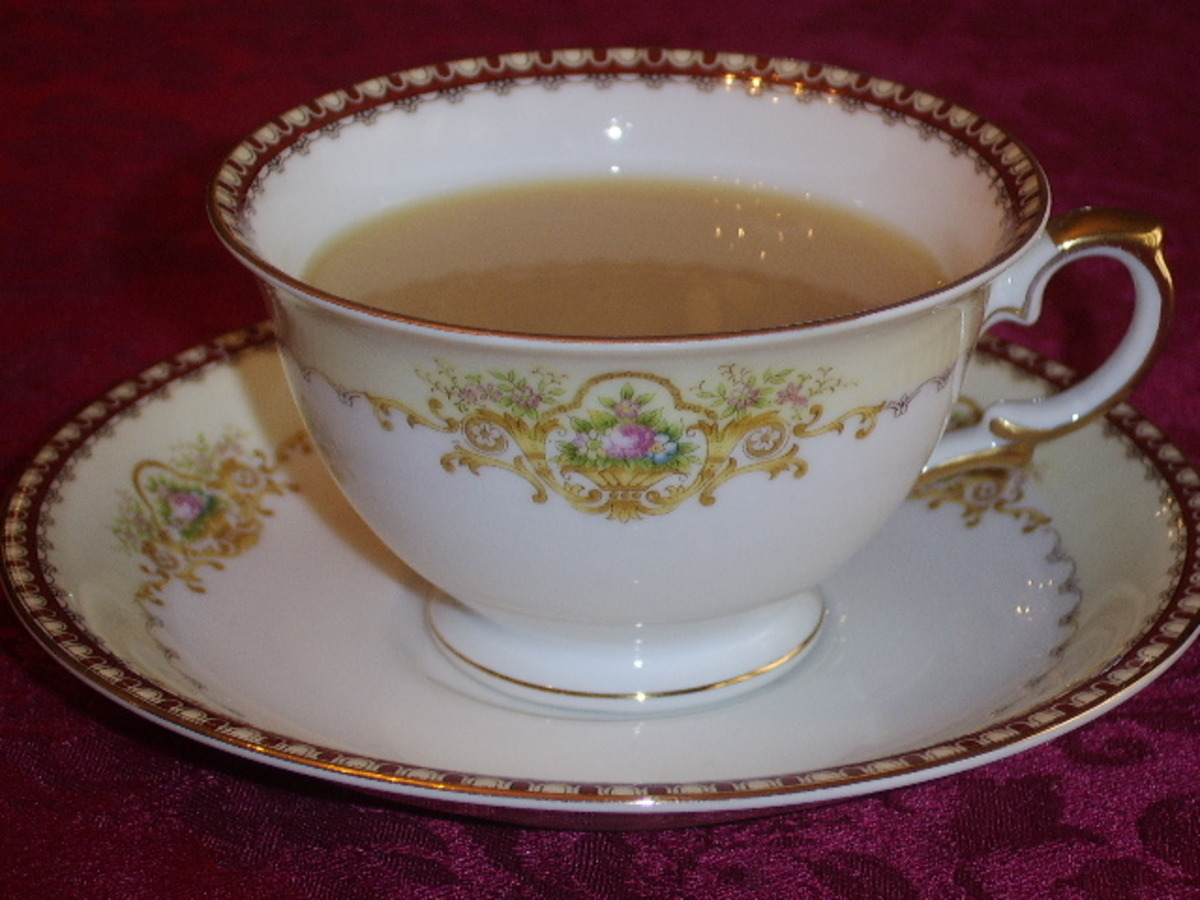

Picture used for this model

This exact approach can power:

* Smart caption generators for social media platforms
* Image search engines
* Visual product recommenders in e-commerce
* Automated marketing content creation
* AI agents that “see” and “talk”

Final Words

So, you’re no longer just working with plain text or static images; you’re bridging vision and language. In just a few lines of Python, you’ve built a Multimodal AI system that would’ve required teams of researchers a few years ago.